In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
from bm3d import bm3d_rgb, BM3DProfile
import sys
module_dir = "/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/bm3d-4.0.3/bm3d-4.0.3/examples" 
sys.path.insert(0, module_dir)
from experiment_funcs import get_experiment_noise, get_psnr, get_cropped_psnr
from PIL import Image
import math
import torch
import torch.nn as nn
import torch.optim as optim
from thop import profile
from einops import rearrange 
from einops.layers.torch import Rearrange, Reduce
from timm.models.layers import trunc_normal_, DropPath

module_dir_scu = "/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/SCUNet" 
sys.path.insert(0, module_dir_scu)
from models.network_scunet import SCUNet as SCUNet
from torch.utils.data import Dataset
from utils import utils_image as util
import joblib
from sklearn.preprocessing import MinMaxScaler

2026-03-26 08:33:28.921759: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774539208.938645 2252414 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774539208.944235 2252414 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774539208.959417 2252414 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774539208.959432 2252414 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774539208.959434 2252414 computation_placer.cc:177] computation placer alr

In [2]:
model_samp = str(240700000)
print("modules loaded")


modules loaded


In [3]:
################# DFT Density !!!!!!!!!!!!!!!!!!!!!
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    ref_d = file['density'][:]

In [4]:
#### test file #######
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]

In [5]:
def D_JS(p1,p2,tol=1e-16):
    p1= p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [6]:
def encode_voxel_to_rgb(test_d, save_path='slice_scalers.npz'):
    """
    Normalize each XY slice independently and encode to RGB (repeated channels).
    Saves (min, max) for each slice for reconstruction.
    
    Returns:
        rgb_volume: (64, 64, 64, 3)
    """
    rgb_volume = np.zeros((64, 64, 64, 3), dtype=np.float32)
    mins = []
    maxs = []

    for i in range(64):
        slice_2d = test_d[i, :, :]
        s_min = float(slice_2d.min())
        s_max = float(slice_2d.max())

        if s_max == s_min:
            s_max = s_min + 1e-6  # Avoid divide-by-zero for flat slices

        normed = (slice_2d - s_min) / (s_max - s_min)
        rgb_volume[i, :, :, :] = np.stack([normed]*3, axis=-1)  # (64, 64, 3)

        mins.append(s_min)
        maxs.append(s_max)

    np.savez(save_path, mins=np.array(mins), maxs=np.array(maxs))
    return rgb_volume  # shape: (64, 64, 64, 3)


In [7]:
def decode_rgb_to_voxel(rgb_volume, save_path='slice_scalers.npz'):
    """
    Decode per-slice normalized RGB volume back into scalar 3D volume.
    Assumes all RGB channels are identical.
    
    Args:
        rgb_volume: shape (64, 64, 64, 3)
    """
    data = np.load(save_path)
    mins = data['mins']
    maxs = data['maxs']

    test_d = np.zeros((64, 64, 64), dtype=np.float32)

    for i in range(64):
        rgb_slice = rgb_volume[i]  # (64, 64, 3)
        gray = rgb_slice[:, :, 0]
        restored = gray * (maxs[i] - mins[i]) + mins[i]
        test_d[i] = restored

    return test_d


In [8]:
print("enc dec loaded")

enc dec loaded


In [9]:
############### scunet_Pretrained ###############

def scunet_pre_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    # Load pretrained model
    model = SCUNet(in_nc=3, config=[4, 4, 4, 4, 4, 4, 4], dim=64)
    model_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/SCUNet/model_zoo/scunet_color_25.pth'  # Adjust if needed
    model.load_state_dict(torch.load(model_path, map_location='cpu'), strict=True)
    model.eval()
    model.to('cuda' if torch.cuda.is_available() else 'cpu')

    def denoise_with_scunet(rgb_image_np, model, device='cuda'):
        """
        Args:
            rgb_image_np: (H, W, 3), float32 or float64, values in [0,1]
            model: SCUNet model
            device: 'cuda' or 'cpu'
        
        Returns:
            Denoised image (H, W, 3), uint8
        """
        # Make sure image is float32 in [0,1]
        img = rgb_image_np.astype(np.float32)
        img_tensor = util.single2tensor4(img).to(device)
        with torch.no_grad():
            output_tensor = model(img_tensor)
        output_np = util.tensor2single(output_tensor)
        return np.clip(output_np.transpose(1, 2, 0), 0, 1)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    

    for i in range(test_rgb.shape[0]):
        
        noisy_slice = test_rgb[i]

        #gray_input = noisy_slice[:, :, 0]  # just one channel
        #denoised_gray = bm3d(gray_input, sigma_psd=sigma)
        #denoised_rgb[i] = np.stack([denoised_gray] * 3, axis=-1)
        denoise =denoise_with_scunet(noisy_slice, model, device=device)
        denoised_rgb[i] = np.transpose(denoise, (0,2,1))
        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)
    #denoised_d = np.mean(denoised_rgb,axis=3)
    #print(np.linalg.norm(denoised_d))
    #print("ref")

    #print(np.linalg.norm(ref_d))
    #print(np.linalg.norm(np.sum(np.mean(ref_rgb,axis=3),axis=0)))

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [10]:
print("scunet pretrained loaded")

scunet pretrained loaded


In [11]:
############### scunet_Trained ###############

def scunet_trained_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    
    torch.serialization.add_safe_globals([SCUNet])
    model = torch.load('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Scunet_trained_Models/'+model_samp+'_scunet_trained', weights_only=False, map_location=torch.device("cpu"))
    model.eval()

    def single2tensor4(img):
        """
        Convert HWC image [0,1] float32 to NCHW tensor
        """
        img_tensor = torch.from_numpy(np.transpose(img, (2, 0, 1))).float().unsqueeze(0)  # shape (1, 3, H, W)
        return img_tensor
    def tensor2single(tensor):
        """
        Convert NCHW or CHW tensor to HWC numpy array, clipped to [0,1]
        """
        tensor = tensor.squeeze().cpu().detach().numpy()
        if tensor.ndim == 3:
            img_np = np.transpose(tensor, (1, 2, 0))  # CHW -> HWC
        else:
            img_np = tensor  # in case it's grayscale
        return np.clip(img_np, 0, 1)


    def denoise_with_scunet(rgb_image_np, model, device='cpu'):
        """
        Denoise a single RGB image using SCUNet.
    
        Args:
            rgb_image_np: (H, W, 3), float32, values in [0,1]
            model: PyTorch SCUNet model
            device: 'cuda' or 'cpu'
    
        Returns:
            Denoised image (H, W, 3), float32 in [0,1]
        """
        img = rgb_image_np.astype(np.float32)
        
        # Ensure range is [0, 1]
        img = np.clip(img, 0, 1)
    
        img_tensor = single2tensor4(img).to(device)
    
        with torch.no_grad():
            output_tensor = model(img_tensor)
    
        output_np = tensor2single(output_tensor)
        return output_np

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    


    
    for i in range(test_rgb.shape[0]):
        noisy_slice = test_rgb[i]  # shape: (H, W, 3)
    
        denoised = denoise_with_scunet(noisy_slice, model, device=device)  # shape: (H, W, 3)
    
        if np.isnan(denoised).any():
            print(f"⚠️ NaNs detected in denoised slice {i}")
    
        denoised_rgb[i] = denoised



        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
       ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d -ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [12]:
print("scunet trained loaded")

scunet trained loaded


In [13]:
############## scunet_TL ##################


def scunet_FT_test_pipeline(test_d, ref_d):
    # Set device first
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)

    # Optional: only needed if loading full model with class definition
    torch.serialization.add_safe_globals([SCUNet])

    # Load model AFTER setting device
    model = torch.load('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Scunet_FT_Models/'+model_samp+'_scunet_FT', map_location='cpu', weights_only=False)
    model.eval()

    def single2tensor4(img):
        """
        Convert HWC image [0,1] float32 to NCHW tensor
        """
        img_tensor = torch.from_numpy(np.transpose(img, (2, 0, 1))).float().unsqueeze(0)  # shape (1, 3, H, W)
        return img_tensor
    def tensor2single(tensor):
        """
        Convert NCHW or CHW tensor to HWC numpy array, clipped to [0,1]
        """
        tensor = tensor.squeeze().cpu().detach().numpy()
        if tensor.ndim == 3:
            img_np = np.transpose(tensor, (1, 2, 0))  # CHW -> HWC
        else:
            img_np = tensor  # in case it's grayscale
        return np.clip(img_np, 0, 1)


    def denoise_with_scunet(rgb_image_np, model, device='cuda'):
        """
        Denoise a single RGB image using SCUNet.
    
        Args:
            rgb_image_np: (H, W, 3), float32, values in [0,1]
            model: PyTorch SCUNet model
            device: 'cuda' or 'cpu'
    
        Returns:
            Denoised image (H, W, 3), float32 in [0,1]
        """
        img = rgb_image_np.astype(np.float32)
        
        # Ensure range is [0, 1]
        img = np.clip(img, 0, 1)
    
        img_tensor = single2tensor4(img).to(device)
    
        with torch.no_grad():
            output_tensor = model(img_tensor)
    
        output_np = tensor2single(output_tensor)
        return output_np

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    


    
    for i in range(test_rgb.shape[0]):
        noisy_slice = test_rgb[i]  # shape: (H, W, 3)
    
        denoised = denoise_with_scunet(noisy_slice, model, device=device)  # shape: (H, W, 3)
    
        if np.isnan(denoised).any():
            print(f"⚠️ NaNs detected in denoised slice {i}")
    
        denoised_rgb[i] = denoised



        

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)

    
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


In [14]:
print("scunet TL loaded")

scunet TL loaded


In [15]:
from keras.models import load_model
import keras

############# Nature #####################
import tensorflow as tf
@tf.keras.utils.register_keras_serializable()
class OnesLikeLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.ones_like(inputs)
def ones_like_fn(a):
    return tf.ones_like(a)
# Now load the model
nature_mod = tf.keras.models.load_model(
    '/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/Nature_Models/'+model_samp+'_Nature.keras',
    custom_objects={'ones_like_fn': ones_like_fn}
)

from keras.layers import Lambda

layer = Lambda(lambda x: x, output_shape=(64, 64, 3))
def Nature_test_pipeline(test_d, ref_d):
    test_rgb = encode_voxel_to_rgb(test_d)
    denoised_rgb = CAE_mod.predict(test_rgb)
    ref_rgb  = encode_voxel_to_rgb(ref_d)
    print(denoised_rgb.shape,"x_test_shape")

    # Denoise each of 64 RGB slices
    #denoised_rgb = np.zeros_like(test_rgb)
    
    #denoised_rgb = nature_mod.predict(noisy_slice)  # shape: (H, W, 3)
    


    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)


I0000 00:00:1774539295.434617 2252414 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38479 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:03:00.0, compute capability: 8.0


In [16]:
print("natrure model loaded")

natrure model loaded


In [17]:
############### CAE_img_enc ###############
from keras.models import load_model
import keras
keras.config.enable_unsafe_deserialization()
CAE_mod = load_model('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_img_Models/'+model_samp+'_2d_CAE_IMG_enc.keras')
from keras.layers import Lambda

def CAE_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    
    denoised_rgb = CAE_mod.predict(test_rgb)  # shape: (H, W, 3)
    



    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)
    


In [18]:
print("CAE img loaded")

CAE img loaded


In [19]:
# Fully working 

################# CAE_full_3D #############
from keras.models import load_model
import keras

############# Nature #####################
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class RenormalizeToEight(tf.keras.layers.Layer):
    def call(self, x):
        total = tf.reduce_sum(x, axis=[1, 2, 3, 4], keepdims=True)
        return x / (total + 1e-8) * 8.0


@tf.keras.utils.register_keras_serializable()
def jensen_shannon_divergence_loss(y_true, y_pred):
    y_t = tf.cast(y_true, tf.float32)
    y_p = tf.cast(y_pred, tf.float32)

    y_t = tf.reshape(y_t, [tf.shape(y_t)[0], -1])
    y_p = tf.reshape(y_p, [tf.shape(y_p)[0], -1])

    y_t /= tf.reduce_sum(y_t, axis=1, keepdims=True) + 1e-8
    y_p /= tf.reduce_sum(y_p, axis=1, keepdims=True) + 1e-8

    m = 0.5 * (y_t + y_p)
    kl_true = tf.reduce_sum(y_t * tf.math.log((y_t + 1e-8) / (m + 1e-8)), axis=1)
    kl_pred = tf.reduce_sum(y_p * tf.math.log((y_p + 1e-8) / (m + 1e-8)), axis=1)
    return tf.reduce_mean(0.5 * (kl_true + kl_pred))
    
from keras.models import load_model
import keras
keras.config.enable_unsafe_deserialization()
CAE_3D_mod = tf.keras.models.load_model(
    '/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models/'+model_samp+'CAE_3D.keras',
    custom_objects={
        "RenormalizeToEight": RenormalizeToEight,
        "jensen_shannon_divergence_loss": jensen_shannon_divergence_loss
    }
)
from keras.layers import Lambda

def CAE_3D_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = test_d
    ref_rgb  = ref_d
    reshaped_arr = test_rgb.reshape(1,64, 64, 64, 1)
    
    denoised_rgb = CAE_3D_mod.predict(reshaped_arr)  # shape: (H, W, 3)
    



    # Reconstruct full 3D volume
    denoised_d = denoised_rgb.reshape(64,64,64)

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics")
    jsd_noisy = jensen_shannon_divergence_loss(test_d,
        ref_d
    )
    jsd_denoised = jensen_shannon_divergence_loss(
        denoised_d,
        ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")

    print(test_d.shape,denoised_d.shape,ref_d.shape)

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised)


In [20]:
print("IMG 3D loaded")

IMG 3D loaded


In [21]:
from bm3d import bm3d
def bm3d_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    N = 100
    sigma = np.sqrt(1.0 / N)
    print("here")
    print(test_rgb.shape)



    #######
    for i in range(64):
        noisy_slice = test_rgb[i]

        gray_input = noisy_slice[:, :, 0]  # just one channel
        denoised_gray = bm3d(gray_input, sigma_psd=sigma)
        denoised_rgb[i] = np.stack([denoised_gray] * 3, axis=-1)

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)

In [22]:
print("BM3D Loaded")

BM3D Loaded


In [23]:
def run_denoising_pipeline(noisy_path, ref_path, model_name, output_file='denoised_output.npy'):
    # convert h5 arrays 
    import h5py
    import numpy as np

    # Load data
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    # Pick model pipeline
    if model_name == 'scunet_trained':
        denoised_density,jsd_denoised =scunet_trained_test_pipeline(test_d, ref_d)
    elif model_name == 'scunet_pre':
        denoised_density,jsd_denoised =scunet_pre_test_pipeline(test_d, ref_d)
    elif model_name == 'scunet_ft':
        denoised_density,jsd_denoised =scunet_FT_test_pipeline(test_d, ref_d)
    elif model_name == 'nature':
        denoised_density,jsd_denoised =Nature_test_pipeline(test_d, ref_d)
    elif model_name == 'CAE':
        denoised_density,jsd_denoised =CAE_test_pipeline(test_d, ref_d)
    elif model_name == 'CAE_3D':
        denoised_density,jsd_denoised =CAE_3D_test_pipeline(test_d, ref_d)
    elif model_name == 'bm3d':
        denoised_density,jsd_denoised =bm3d_test_pipeline(test_d, ref_d)
    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    # Save denoised result
    #np.save(output_file, denoised_density)
    print(f"\n Denoised matrix saved to {output_file}")
    return(denoised_density,jsd_denoised)


In [29]:
print(noisy_files)

['/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Data_Gen/plot_data/Image_Den_Plot_allM/density_tot_vmc_mean_0000081920.h5']


Found 1 noisy files.

=== Running model: scunet_trained ===

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.090134
JSD   (denoised vs ref):  0.000648

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.090134
JSD   (denoised vs ref):  0.000648


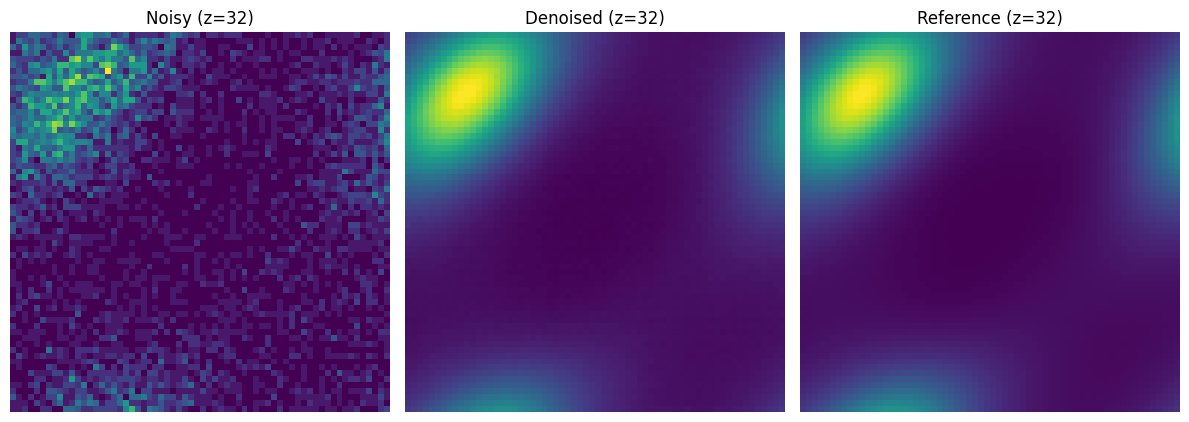


 Denoised matrix saved to denoised_output.npy
Sample 81920 | scunet_trained JSD = 0.000648 | Saved -> density_sample_81920_scunet_trained.npy

=== Running model: scunet_pre ===
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial Type: SW, drop_path_rate:0.000000
Block Initial Type: W, drop_path_rate:0.000000
Block Initial T

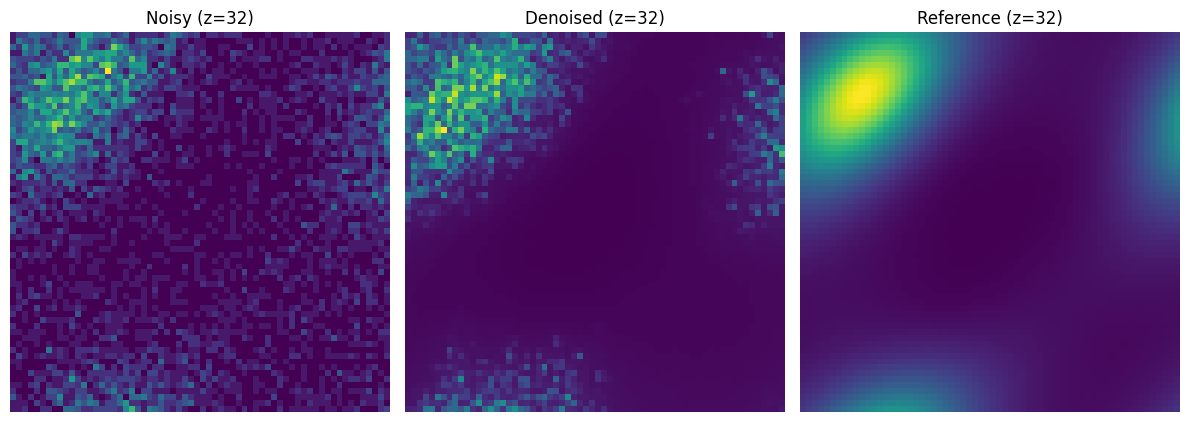


 Denoised matrix saved to denoised_output.npy
Sample 81920 | scunet_pre JSD = 0.025921 | Saved -> density_sample_81920_scunet_pre.npy

=== Running model: scunet_ft ===

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.090134
JSD   (denoised vs ref):  0.000612

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0011
JSD   (noisy vs ref):     0.090134
JSD   (denoised vs ref):  0.000612


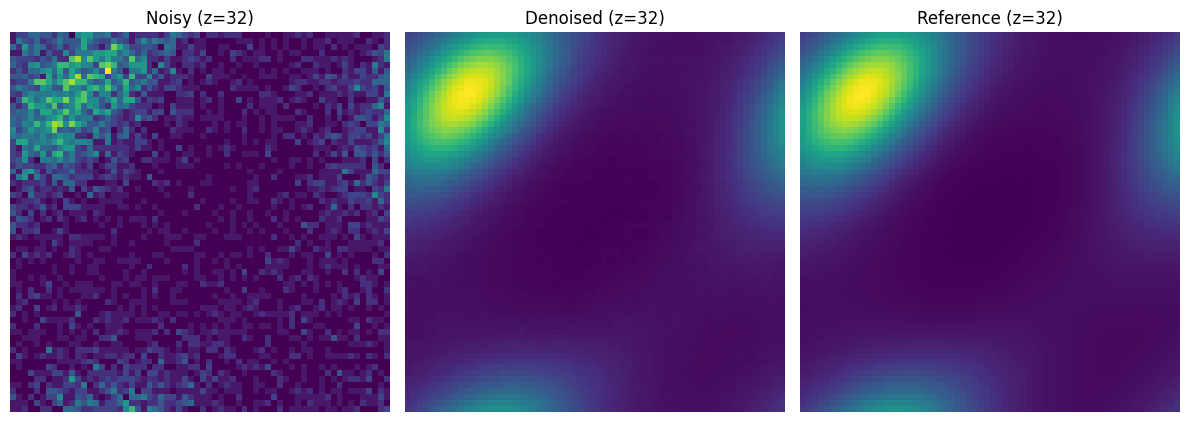


 Denoised matrix saved to denoised_output.npy
Sample 81920 | scunet_ft JSD = 0.000612 | Saved -> density_sample_81920_scunet_ft.npy

=== Running model: nature ===


I0000 00:00:1774539315.110705 2252570 service.cc:152] XLA service 0x7f2f9c004020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774539315.110744 2252570 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-03-26 08:35:15.129984: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774539315.201877 2252570 cuda_dnn.cc:529] Loaded cuDNN version 90300


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


I0000 00:00:1774539316.420868 2252570 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


(64, 64, 64, 3) x_test_shape

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0018
JSD   (noisy vs ref):     0.090134
JSD   (denoised vs ref):  0.001355

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0018
JSD   (noisy vs ref):     0.090134
JSD   (denoised vs ref):  0.001355


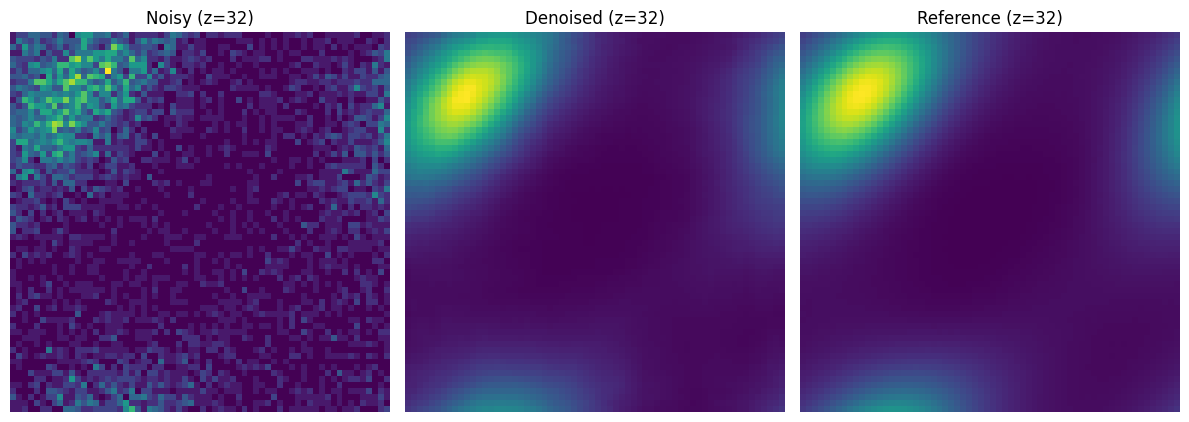


 Denoised matrix saved to denoised_output.npy
Sample 81920 | nature JSD = 0.001355 | Saved -> density_sample_81920_nature.npy

=== Running model: CAE ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0018
JSD   (noisy vs ref):     0.090134
JSD   (denoised vs ref):  0.001355

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0018
JSD   (noisy vs ref):     0.090134
JSD   (denoised vs ref):  0.001355


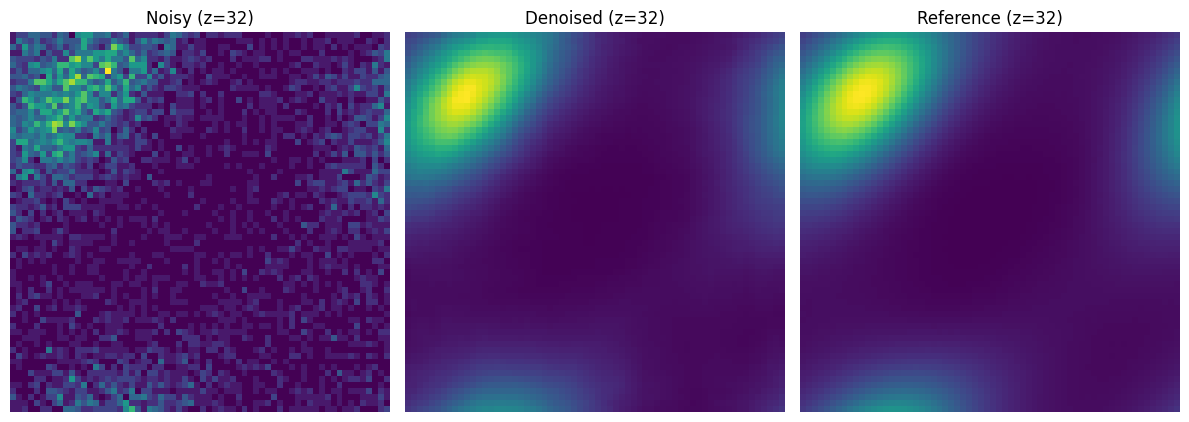


 Denoised matrix saved to denoised_output.npy
Sample 81920 | CAE JSD = 0.001355 | Saved -> density_sample_81920_CAE.npy

=== Running model: bm3d ===
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0101
JSD   (noisy vs ref):     0.090134
JSD   (denoised vs ref):  0.014359

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0101
JSD   (noisy vs ref):     0.090134
JSD   (denoised vs ref):  0.014359


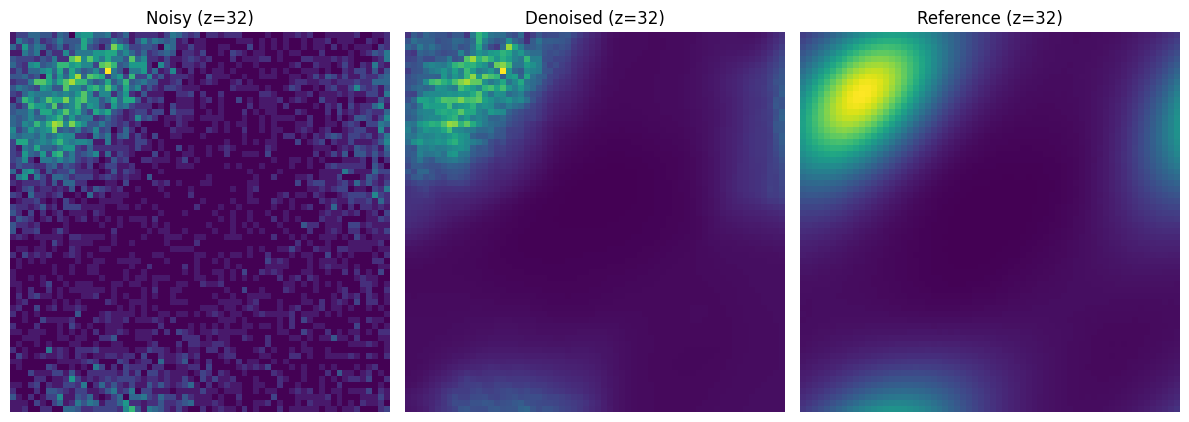


 Denoised matrix saved to denoised_output.npy
Sample 81920 | bm3d JSD = 0.014359 | Saved -> density_sample_81920_bm3d.npy


In [24]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py

# ================= CPU-loading patch =================
_original_torch_load = torch.load
def torch_load_cpu(*args, **kwargs):
    if 'map_location' not in kwargs:
        kwargs['map_location'] = torch.device('cpu')
    return _original_torch_load(*args, **kwargs)
torch.load = torch_load_cpu

# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Data_Gen/plot_data/Image_Den_Plot_allM"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

models = [
    'scunet_trained',
    'scunet_pre',
    'scunet_ft',
    'nature',
    'CAE',
    'bm3d'
]

print(f"Found {len(noisy_files)} noisy files.")

# ================= Reference JSD =================
results_ref = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    jsd = D_JS(ref_d, test_d)
    results_ref.append((sample_num, jsd))

results_array_ref = np.array(sorted(results_ref, key=lambda x: x[0]))

# ================= Run models =================
# ================= Run models =================
results_dict = {model: [] for model in models}

for model_name in models:
    print(f"\n=== Running model: {model_name} ===")

    for noisy_path in noisy_files:
        match = re.search(r"(\d+)\.h5$", noisy_path)
        if not match:
            continue
        sample_num = int(match.group(1))

        # ---- Clean, explicit naming ----
        output_file = f"density_sample_{sample_num}_{model_name}.npy"
        output_path = os.path.join(base_dir, output_file)

        # ---- Run model ----
        denoised_den, jsd = run_denoising_pipeline(
            noisy_path,
            ref_path,
            model_name
        )

        # ---- FORCE SAVE (this is the important part) ----
        np.save(output_path, denoised_den)

        # ---- Track metrics ----
        results_dict[model_name].append((sample_num, jsd))
        print(f"Sample {sample_num} | {model_name} JSD = {jsd:.6f} | Saved -> {output_file}")


[DEBUG] findfont: Matching sans\-serif:style=normal:variant=normal:weight=bold:stretch=normal:size=20.0.
[DEBUG] findfont: score(FontEntry(fname='/global/u2/k/kberard/environments/SCGSR/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizTwoSymBol.ttf', name='STIXSizeTwoSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.05
[DEBUG] findfont: score(FontEntry(fname='/global/u2/k/kberard/environments/SCGSR/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFiveSymReg.ttf', name='STIXSizeFiveSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
[DEBUG] findfont: score(FontEntry(fname='/global/u2/k/kberard/environments/SCGSR/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Bold.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.05
[DEBUG] findfont: score(FontEntry(fname='/global/u2/k/kberard/envi

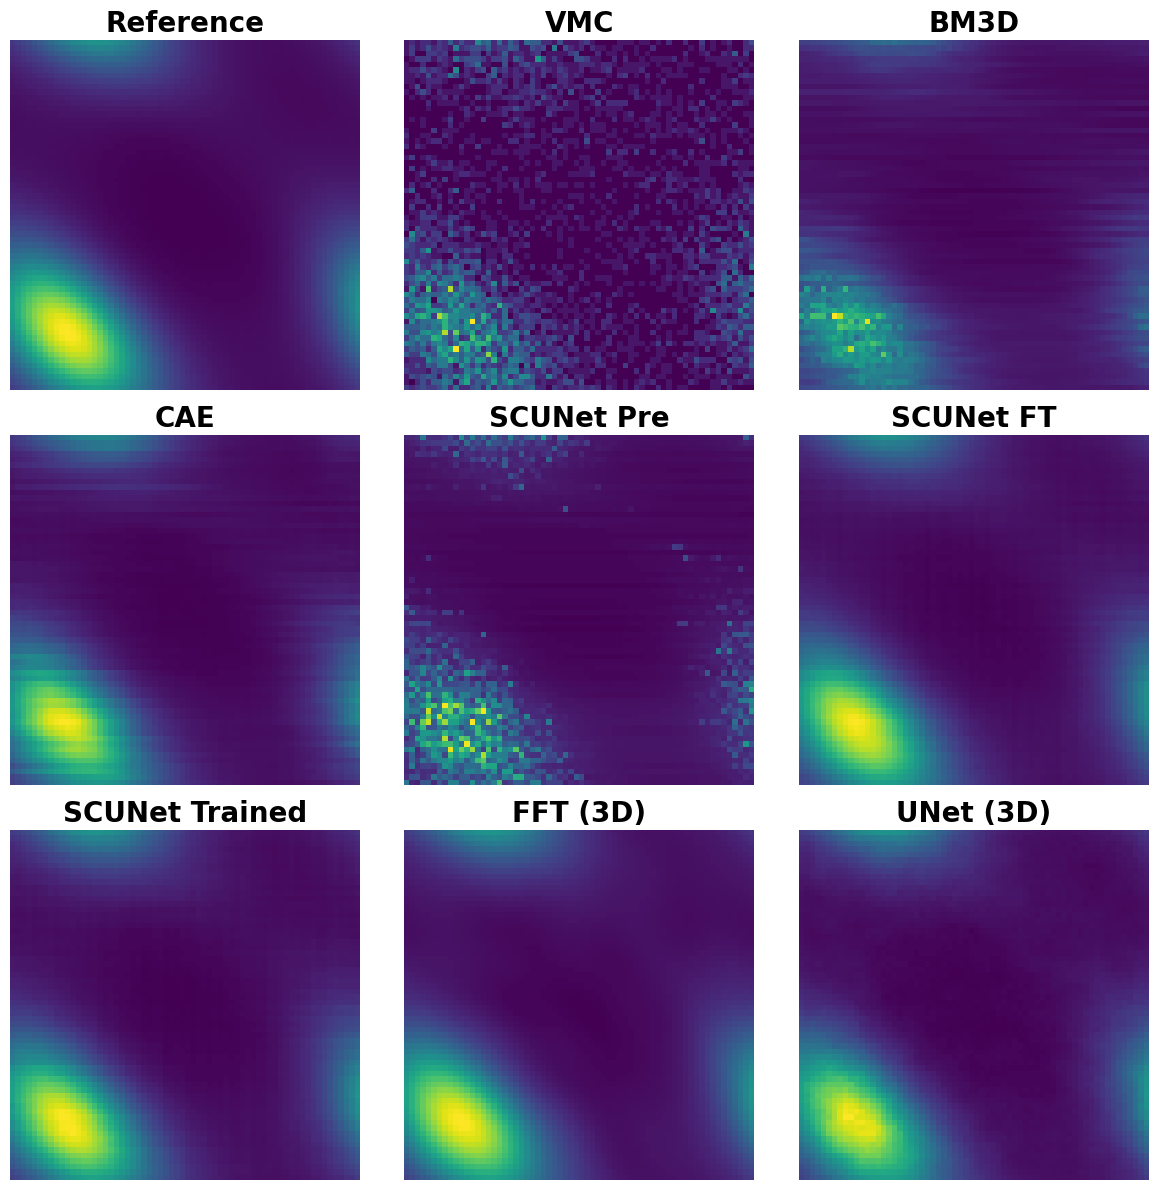

In [49]:
import os
import glob
import h5py
import numpy as np
import matplotlib.pyplot as plt

base_dir = "/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Data_Gen/plot_data/Image_Den_Plot_allM"

# ================= Load reference =================
with h5py.File(os.path.join(base_dir, "density_tot_ref_mean.h5"), 'r') as f:
    ref_d = f['density'][:]

# ================= Load VMC =================
vmc_file = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean_*.h5")))[0]
with h5py.File(vmc_file, 'r') as f:
    vmc_d = f['density'][:]

# ================= Load model outputs =================
npy_files = glob.glob(os.path.join(base_dir, "density_sample_*_*.npy"))

model_dict = {}
for fpath in npy_files:
    name = os.path.basename(fpath)
    if "nature" in name:
        continue

    data = np.load(fpath)

    if "bm3d" in name:
        model_dict["bm3d"] = data
    elif "CAE" in name:
        model_dict["CAE"] = data
    elif "scunet_pre" in name:
        model_dict["unet_pre"] = data
    elif "scunet_ft" in name:
        model_dict["unet_ft"] = data
    elif "scunet_trained" in name:
        model_dict["unet_trained"] = data
    elif "UNET_3D" in name:
        model_dict["unet3d"] = data
    elif "FFT_3D" in name:
        model_dict["fft"] = data

# ================= Build EXACT 3x3 layout =================
all_data = [
    ("Reference", ref_d),
    ("VMC", vmc_d),
    ("BM3D", model_dict.get("bm3d")),
    ("CAE", model_dict.get("CAE")),
    ("SCUNet Pre", model_dict.get("unet_pre")),
    ("SCUNet FT", model_dict.get("unet_ft")),
    ("SCUNet Trained", model_dict.get("unet_trained")),
    ("FFT (3D)", model_dict.get("fft")),     # last row, 2nd col
    ("UNet (3D)", model_dict.get("unet3d")), # last row, 3rd col
]

# ================= Plot 3x3 grid with bold, larger titles =================
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, (name, data) in enumerate(all_data):
    ax = axes[i]

    if data is None:
        ax.axis('off')
        continue

    central_slice = data[:, :, data.shape[2] // 2]
    # auto-scale colors individually
    im = ax.imshow(central_slice, origin='lower')
    ax.set_title(name, fontsize=20, fontweight='bold')  # <-- bold & larger
    ax.axis('off')

plt.tight_layout()
plt.show()

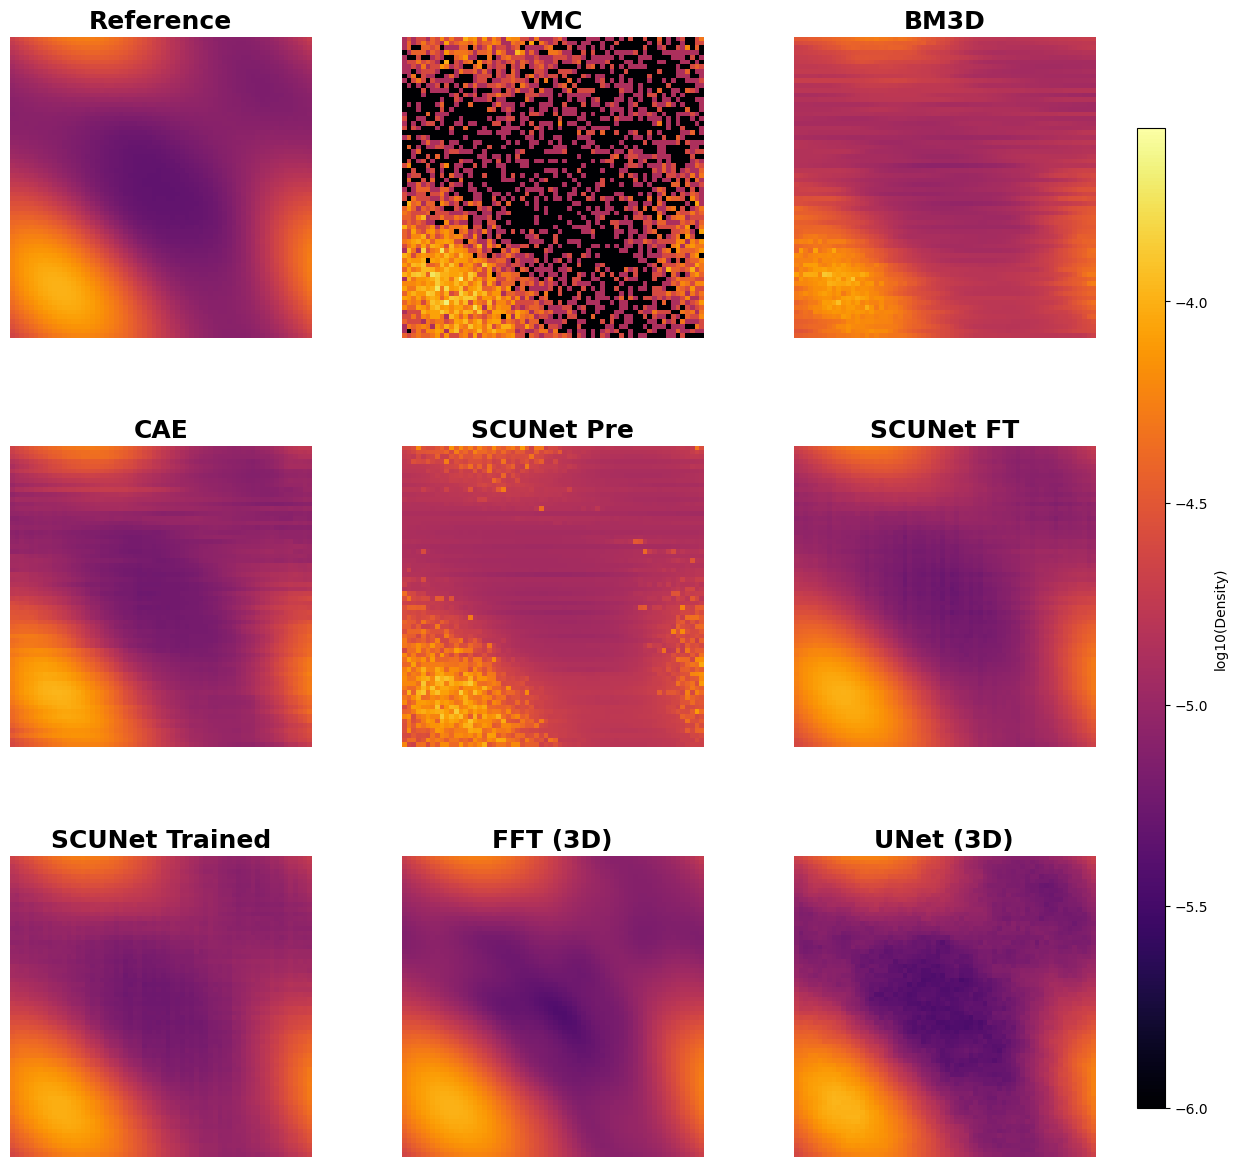

In [1]:
import os
import glob
import h5py
import numpy as np
import matplotlib.pyplot as plt
def D_JS(p1,p2,tol=1e-16):
    p1= p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

base_dir = "/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Data_Gen/plot_data/Image_Den_Plot_allM"

eps = 1e-6  # small number to avoid log(0)

# ================= Load reference =================
with h5py.File(os.path.join(base_dir, "density_tot_ref_mean.h5"), 'r') as f:
    ref_d = f['density'][:]
    ref_d = ref_d * (8 / np.sum(ref_d))

# ================= Load VMC =================
vmc_file = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean_*.h5")))[0]
with h5py.File(vmc_file, 'r') as f:
    vmc_d = f['density'][:]
    vmc_d = vmc_d * (8 / np.sum(vmc_d))

# ================= Load model outputs =================
npy_files = glob.glob(os.path.join(base_dir, "density_sample_*_*.npy"))

model_dict = {}
for fpath in npy_files:
    name = os.path.basename(fpath)
    if "nature" in name:
        continue

    data = np.load(fpath)
    data = data * (8 / np.sum(data))  # normalize

    if "bm3d" in name:
        model_dict["bm3d"] = data
    elif "CAE" in name:
        model_dict["CAE"] = data
    elif "scunet_pre" in name:
        model_dict["unet_pre"] = data
    elif "scunet_ft" in name:
        model_dict["unet_ft"] = data
    elif "scunet_trained" in name:
        model_dict["unet_trained"] = data
    elif "UNET_3D" in name:
        model_dict["unet3d"] = data
    elif "FFT_3D" in name:
        model_dict["fft"] = data

# ================= Build EXACT 3x3 layout =================
all_data = [
    ("Reference", ref_d),
    ("VMC", vmc_d),
    ("BM3D", model_dict.get("bm3d")),
    ("CAE", model_dict.get("CAE")),
    ("SCUNet Pre", model_dict.get("unet_pre")),
    ("SCUNet FT", model_dict.get("unet_ft")),
    ("SCUNet Trained", model_dict.get("unet_trained")),
    ("FFT (3D)", model_dict.get("fft")),
    ("UNet (3D)", model_dict.get("unet3d")),
]

# ================= Log transform =================
all_data_log = [(name, np.log10(data + eps) if data is not None else None) for name, data in all_data]

# ================= Compute global vmin / vmax =================
valid_data = [d for _, d in all_data_log if d is not None]
vmin = min(np.min(d) for d in valid_data)
vmax = max(np.max(d) for d in valid_data)

# ================= Plot 3x3 grid =================
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

for i, (name, data) in enumerate(all_data_log):
    ax = axes[i]
    if data is None:
        ax.axis('off')
        continue

    central_slice = data[:, :, data.shape[2] // 2]
    im = ax.imshow(central_slice, origin='lower', vmin=vmin, vmax=vmax, cmap="inferno")
    ax.set_title(name, fontsize=18, fontweight='bold')  # large & bold titles
    ax.axis('off')

# Adjust layout to leave space for titles
fig.subplots_adjust(top=0.92, hspace=0.3, wspace=0.3)

# Add a single colorbar on the right
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='log10(Density)')

plt.show()

In [4]:
import sys
import os
import re
import numpy as np
import h5py
base_dir = "/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Data_Gen/plot_data/Image_Den_Plot_allM"
noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 
# ================= Load reference =================
with h5py.File(os.path.join(base_dir, "density_tot_ref.h5"), 'r') as f:
    dft_d = f['density'][:]
sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

#! /usr/bin/env python3

from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil

def div_js_dens(d1, d2):
    return D_JS(d1, d2)

model_name = "fft"  # consistent naming with your other models
model_results_FFT = []

for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    # ---- Load noisy density ----
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    # ---- Run FFT denoiser ----
    dm = DensityFourierFilterErrorCeil(
        density_ref=dft_d,
        filter_mode='augment'
    )

    d_denoised = dm.denoise(test_d)



    np.save('/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Data_Gen/plot_data/Image_Den_Plot_allM/density_sample_81920_FFT_3D.npy', d_denoised)



[DEBUG] matplotlib data path: /global/u2/k/kberard/environments/SCGSR/lib/python3.12/site-packages/matplotlib/mpl-data
[DEBUG] CONFIGDIR=/global/u2/k/kberard/.config/matplotlib
[DEBUG] interactive is False
[DEBUG] platform is linux
[DEBUG] CACHEDIR=/global/u2/k/kberard/.cache/matplotlib
[DEBUG] Using fontManager instance from /global/u2/k/kberard/.cache/matplotlib/fontlist-v390.json
[DEBUG] Loaded backend module://matplotlib_inline.backend_inline version unknown.
[DEBUG] Loaded backend module://matplotlib_inline.backend_inline version unknown.
[DEBUG] findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
[DEBUG] findfont: score(FontEntry(fname='/global/u2/k/kberard/environments/SCGSR/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizTwoSymBol.ttf', name='STIXSizeTwoSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
[DEBUG] findfont: score(FontEntry(fname='/global/u2/k/kberard/envi

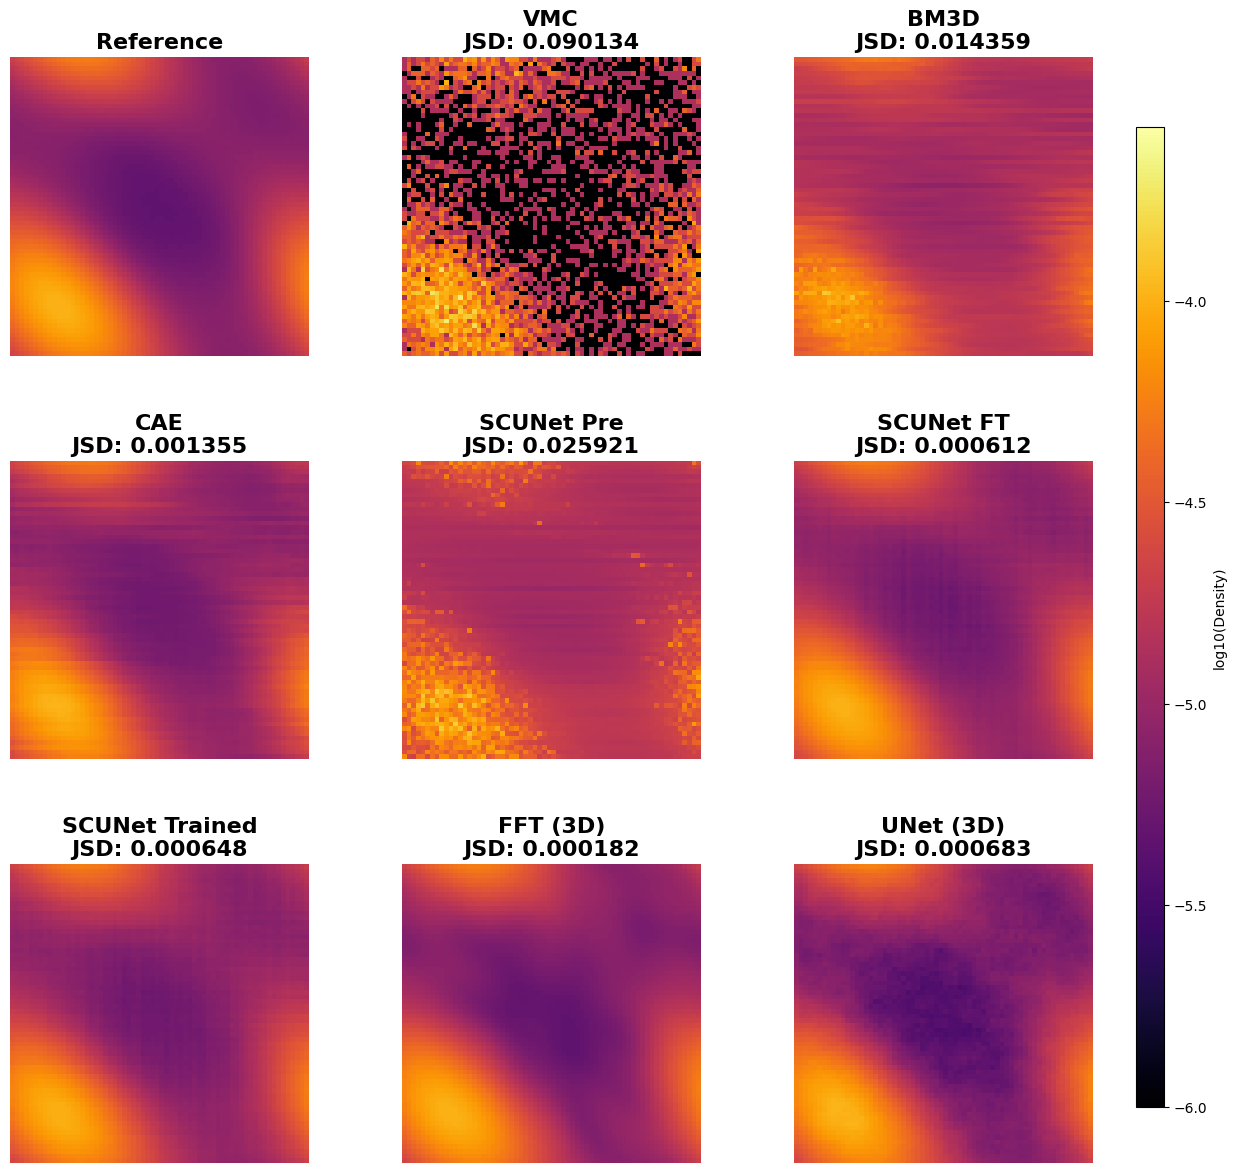

In [5]:
import os
import glob
import h5py
import numpy as np
import matplotlib.pyplot as plt

def D_JS(p1,p2,tol=1e-16):
    p1 = p1/np.sum(p1)
    p2 = p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

base_dir = "/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Data_Gen/plot_data/Image_Den_Plot_allM"

eps = 1e-6  # small number to avoid log(0)

# ================= Load reference =================
with h5py.File(os.path.join(base_dir, "density_tot_ref_mean.h5"), 'r') as f:
    ref_d = f['density'][:]
    ref_d = ref_d * (8 / np.sum(ref_d))

# ================= Load VMC =================
vmc_file = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean_*.h5")))[0]
with h5py.File(vmc_file, 'r') as f:
    vmc_d = f['density'][:]
    vmc_d = vmc_d * (8 / np.sum(vmc_d))

# ================= Load model outputs =================
npy_files = glob.glob(os.path.join(base_dir, "density_sample_*_*.npy"))

model_dict = {}
for fpath in npy_files:
    name = os.path.basename(fpath)
    if "nature" in name:
        continue

    data = np.load(fpath)
    data = data * (8 / np.sum(data))  # normalize

    if "bm3d" in name:
        model_dict["bm3d"] = data
    elif "CAE" in name:
        model_dict["CAE"] = data
    elif "scunet_pre" in name:
        model_dict["unet_pre"] = data
    elif "scunet_ft" in name:
        model_dict["unet_ft"] = data
    elif "scunet_trained" in name:
        model_dict["unet_trained"] = data
    elif "UNET_3D" in name:
        model_dict["unet3d"] = data
    elif "FFT_3D" in name:
        model_dict["fft"] = data

# ================= Build EXACT 3x3 layout =================
all_data = [
    ("Reference", ref_d),
    ("VMC", vmc_d),
    ("BM3D", model_dict.get("bm3d")),
    ("CAE", model_dict.get("CAE")),
    ("SCUNet Pre", model_dict.get("unet_pre")),
    ("SCUNet FT", model_dict.get("unet_ft")),
    ("SCUNet Trained", model_dict.get("unet_trained")),
    ("FFT (3D)", model_dict.get("fft")),
    ("UNet (3D)", model_dict.get("unet3d")),
]

# ================= Compute JSD and Log transform =================
# We compute JSD on the raw data, but pass the log-transformed data for plotting
all_data_processed = []
for name, data in all_data:
    if data is not None:
        jsd_score = D_JS(data, ref_d)
        log_data = np.log10(data + eps)
    else:
        jsd_score = None
        log_data = None
    all_data_processed.append((name, log_data, jsd_score))

# ================= Compute global vmin / vmax =================
valid_data = [d for _, d, _ in all_data_processed if d is not None]
vmin = min(np.min(d) for d in valid_data)
vmax = max(np.max(d) for d in valid_data)

# ================= Plot 3x3 grid =================
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

for i, (name, data_log, jsd_score) in enumerate(all_data_processed):
    ax = axes[i]
    if data_log is None:
        ax.axis('off')
        continue

    central_slice = data_log[:, :, data_log.shape[2] // 2]
    im = ax.imshow(central_slice, origin='lower', vmin=vmin, vmax=vmax, cmap="inferno")
    
    # Format the title to include the JSD score (skipping it for the Reference plot)
    if name == "Reference":
        title_str = name
    else:
        title_str = f"{name}\nJSD: {jsd_score:.6f}"
        
    ax.set_title(title_str, fontsize=16, fontweight='bold')  # Reduced font slightly to fit 2 lines
    ax.axis('off')

# Adjust layout to leave space for two-line titles
fig.subplots_adjust(top=0.90, hspace=0.35, wspace=0.3)

# Add a single colorbar on the right
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='log10(Density)')

plt.show()

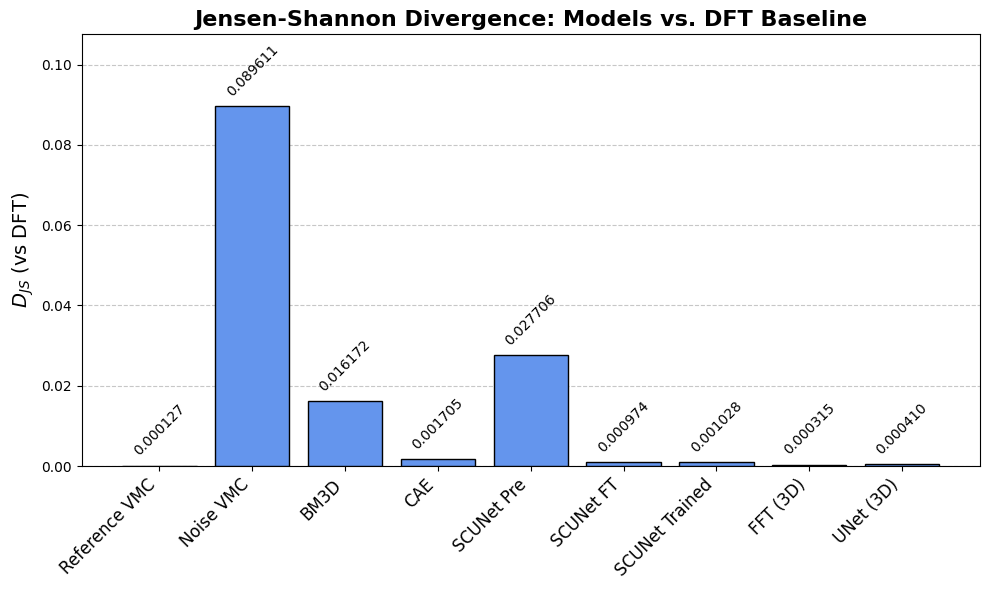

In [8]:
import os
import glob
import h5py
import numpy as np
import matplotlib.pyplot as plt

def D_JS(p1, p2, tol=1e-16):
    p1 = p1 / np.sum(p1)
    p2 = p2 / np.sum(p2)
    pm = (p1 + p2) / 2
    p1_nonzero = np.abs(p1) > tol
    p2_nonzero = np.abs(p2) > tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5 * ( (p1 * np.log(p1 / pm1)).sum() + (p2 * np.log(p2 / pm2)).sum() )
    d /= np.log(2)  # normalize to max of 1
    return d

base_dir = "/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Data_Gen/plot_data/Image_Den_Plot_allM"

# ================= Load DFT =================
with h5py.File(os.path.join(base_dir, "density_tot_ref.h5"), 'r') as f:
    dft_d = f['density'][:]
    dft_d = dft_d * (8 / np.sum(dft_d))

# ================= Load Reference =================
with h5py.File(os.path.join(base_dir, "density_tot_ref_mean.h5"), 'r') as f:
    ref_d = f['density'][:]
    ref_d = ref_d * (8 / np.sum(ref_d))

# ================= Load VMC =================
vmc_file = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean_*.h5")))[0]
with h5py.File(vmc_file, 'r') as f:
    vmc_d = f['density'][:]
    vmc_d = vmc_d * (8 / np.sum(vmc_d))

# ================= Load Model Outputs =================
npy_files = glob.glob(os.path.join(base_dir, "density_sample_*_*.npy"))

model_dict = {}
for fpath in npy_files:
    name = os.path.basename(fpath)
    if "nature" in name: continue

    data = np.load(fpath)
    data = data * (8 / np.sum(data))  # normalize

    if "bm3d" in name: model_dict["bm3d"] = data
    elif "CAE" in name: model_dict["CAE"] = data
    elif "scunet_pre" in name: model_dict["unet_pre"] = data
    elif "scunet_ft" in name: model_dict["unet_ft"] = data
    elif "scunet_trained" in name: model_dict["unet_trained"] = data
    elif "UNET_3D" in name: model_dict["unet3d"] = data
    elif "FFT_3D" in name: model_dict["fft"] = data

all_data = [
    ("Reference VMC", ref_d),
    ("Noise VMC", vmc_d),
    ("BM3D", model_dict.get("bm3d")),
    ("CAE", model_dict.get("CAE")),
    ("SCUNet Pre", model_dict.get("unet_pre")),
    ("SCUNet FT", model_dict.get("unet_ft")),
    ("SCUNet Trained", model_dict.get("unet_trained")),
    ("FFT (3D)", model_dict.get("fft")),
    ("UNet (3D)", model_dict.get("unet3d")),
]

# ================= Process JSD vs DFT =================
dft_jsd_names = []
dft_jsd_scores = []

for name, data in all_data:
    if data is not None:
        score = D_JS(data, dft_d)
        dft_jsd_names.append(name)
        dft_jsd_scores.append(score)

# ================= Plot Bar Chart =================
fig, ax_bar = plt.subplots(figsize=(10, 6))

bars = ax_bar.bar(dft_jsd_names, dft_jsd_scores, color='cornflowerblue', edgecolor='black', zorder=3)

# Formatting the bar plot
ax_bar.set_ylabel('$D_{JS}$ (vs DFT)', fontsize=14)
ax_bar.set_title('Jensen-Shannon Divergence: Models vs. DFT Baseline', fontsize=16, fontweight='bold')
ax_bar.set_xticks(range(len(dft_jsd_names)))
ax_bar.set_xticklabels(dft_jsd_names, rotation=45, ha='right', fontsize=12)
ax_bar.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

# Add exact numeric labels slightly above each bar
max_y = max(dft_jsd_scores)
for bar in bars:
    yval = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width() / 2, yval + (max_y * 0.02), 
                f'{yval:.6f}', ha='center', va='bottom', fontsize=10, rotation=45)

# Adjust y-axis limit slightly so the text doesn't get cut off
ax_bar.set_ylim(0, max_y * 1.2)

fig.tight_layout()
plt.show()